# **Project Overview**

**Problem Statement**

**Business Objective**

**Dataset Description**

## **1. Import Libraries**

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## **2. Load and Explore Dataset**

**Load CSV and Display Dataset**

In [4]:
df = pd.read_csv('data/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**Display Shape**

In [5]:
df.shape

(6362620, 11)

**Display Dataset Info**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


**Drop ID Coloumns and isFlaggedFraud**

In [7]:
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

**Count Null Values**

In [8]:
df.isna().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

**Count Duplicates**

In [9]:
df.duplicated().sum()

np.int64(543)

In [10]:
df = df.drop_duplicates()

**Summary Statistics**

In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362077.0,NaN,NaN,NaN,243.399529,142.33233,1.0,156.0,239.0,335.0,743.0
type,6362077,5,CASH_OUT,2237484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362077.0,NaN,NaN,NaN,179853.072675,603693.667054,0.0,13394.07,74893.34,208732.96,92445516.64
oldbalanceOrg,6362077.0,NaN,NaN,NaN,833930.698363,2888321.643696,0.0,0.0,14218.0,107326.0,59585040.37
newbalanceOrig,6362077.0,NaN,NaN,NaN,855186.65209,2924162.611142,0.0,0.0,0.0,144292.52,49585040.37
oldbalanceDest,6362077.0,NaN,NaN,NaN,1100795.610841,3399309.958137,0.0,0.0,132783.41,943171.77,356015889.35
newbalanceDest,6362077.0,NaN,NaN,NaN,1225077.373809,3674244.077873,0.0,0.0,214738.54,1112050.52,356179278.92
isFraud,6362077.0,NaN,NaN,NaN,0.001288,0.035871,0.0,0.0,0.0,0.0,1.0


## **3. EDA**

In [12]:
df_eda = df.copy()

**Check Target Distibution for Imbalance**

The target variable is highly imbalanced, with 99.9% legitimate transactions and 0.1% fraudulent transactions. This distribution is typical of real-world fraud detection datasets and is expected for this type of problem.

In [13]:
counts = df_eda['isFraud'].value_counts()
pct = df_eda['isFraud'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': counts, 'pct': pct.round(2)})

summary

,count,pct
isFraud,,
0,6353880,99.87
1,8197,0.13


**Transaction Type vs Fraud**

Fraudulent transaction can be observed only in `TRANSFER` and `CASH_OUT` transactiontypes. No fraud cases were recored for `PAYMENT`, `DEBIT`, or `CASH_IN`, suggesting that fraudlent activities in this dataset only happens in money transfers and cash withdrawals.

In [14]:
type_fraud = df.groupby('type')['isFraud'].agg(['count','sum','mean'])
type_fraud 

,count,sum,mean
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237484,4100,0.001832
DEBIT,41432,0,0.000000
PAYMENT,2150968,0,0.000000
TRANSFER,532909,4097,0.007688


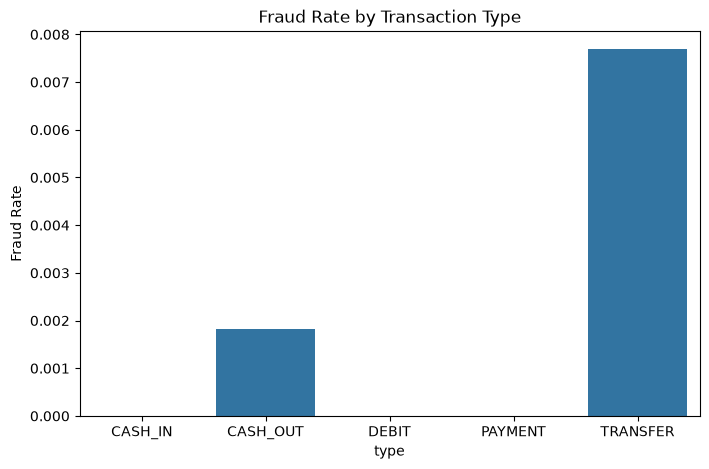

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x=type_fraud.index, y=type_fraud['mean'])
plt.title('Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

**Amount Distribution**

We can observe that, in this dataset, fraudulent activities tend to involve larger amounts of money compared to non-fraudulent ones. But, since there is overlap between them, this is not absolute, `log_amount` alone cannot reliably classify fraud. However, its distinct distributional shift makes it a strong predictive feature when combined with other indicators in a model.

In [16]:
df_eda['log_amount'] = np.log1p(df_eda['amount'])

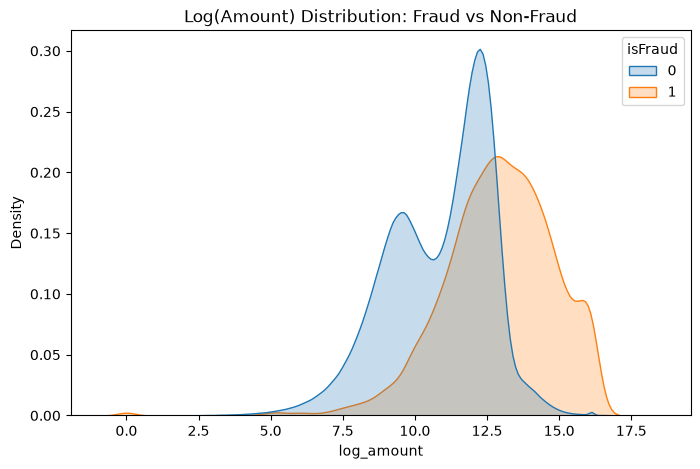

In [17]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_eda, x='log_amount', hue='isFraud', common_norm=False, fill=True)
plt.title('Log(Amount) Distribution: Fraud vs Non-Fraud')
plt.show()

**Correlation HeatMap**

We can observe near-zero `isFraud` values for this HeatMap; this explains that using models may not effectively capture the relationships between variables, suggesting that non-linear algorithms or tree-based models would be better suited for this dataset.

In [18]:
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']

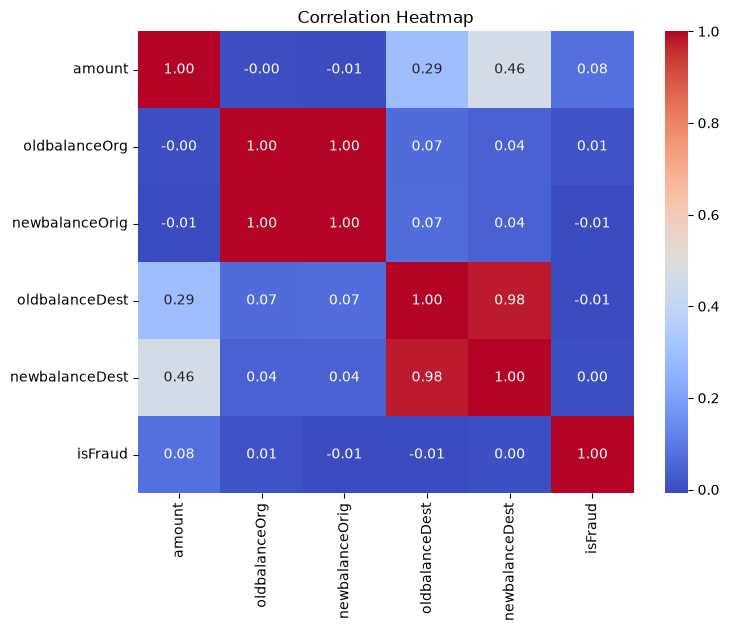

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df_eda[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## **4. Data Pre-processing**

**Encode Categorical Features (`type`)**

In [20]:
df_encoded = pd.get_dummies(
    df, 
    columns=['type'],
    drop_first=True
)

In [21]:
df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False


**Separate Features and Target**

In [22]:
X = df_encoded.drop(columns=['isFraud'])

In [23]:
y = df_encoded['isFraud']

# **5. Train Test Split**

**Split Train and Test**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

**Check Distribution of `isFraud`**

Given the severe class imbalance in this dataset, stratified sampling is essential to ensures all train/test splits and cross-validation folds maintain the original ratio of fraud to non-fraud.

In [25]:
train_balance = pd.DataFrame({
    'count': y_train.value_counts(),
    'percent': (y_train.value_counts(normalize=True) * 100).round(2)
})
train_balance.index.name = 'isFraud'

In [26]:
train_balance

,count,percent
isFraud,,
0,4447715,99.87
1,5738,0.13


# **6. Model Training**

**Logistic Regression (Baseline)**

In [27]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1)
log_reg.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",1
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default i

**Decision Tree**

In [28]:
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=1)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

**Random Forest**

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=1,
    n_jobs=3
)

In [30]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

# **7. Model Evaluation**

With fraud at ~0.13% of transactions, accuracy is not useful (predicting "not fraud" every time would score ~99.9%). Instead we prioritize:

- **Recall (of the fraud class)** - Out of all real fraud cases, how many did we catch?
- **Precision (of the fraud class)** - Out of everything we flagged as fraud, how many actually were?
- **F1-score** - A single score that balances both Precision and Recall.
- **PR-AUC (Average Precision)** - Measures overall model performance amidst heavy class imbalance
- **Confusion Matrix** - Displays the exact count of missed fraud (False Negatives) versus false alarms (False Positives).

**Evaluate Function**

In [43]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_proba)

    print(f"-_- {name} -_-")
    print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
    print(f"Precision (Fraud): {precision:.4f}")
    print(f"Recall (Fraud):    {recall:.4f}")
    print(f"F1-score (Fraud):  {f1:.4f}")
    print(f"PR-AUC:            {pr_auc:.4f}")

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Not Fraud', 'Fraud'], cmap='Blues'
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    return {
        'model': name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'pr_auc': pr_auc,
        'y_proba': y_proba
    }

**Logistic Regression**

-_- Logistic Regression -_-
              precision    recall  f1-score   support

   Not Fraud       1.00      0.96      0.98   1906165
       Fraud       0.03      0.92      0.06      2459

    accuracy                           0.96   1908624
   macro avg       0.51      0.94      0.52   1908624
weighted avg       1.00      0.96      0.98   1908624

Precision (Fraud): 0.0298
Recall (Fraud):    0.9211
F1-score (Fraud):  0.0577
PR-AUC:            0.5720


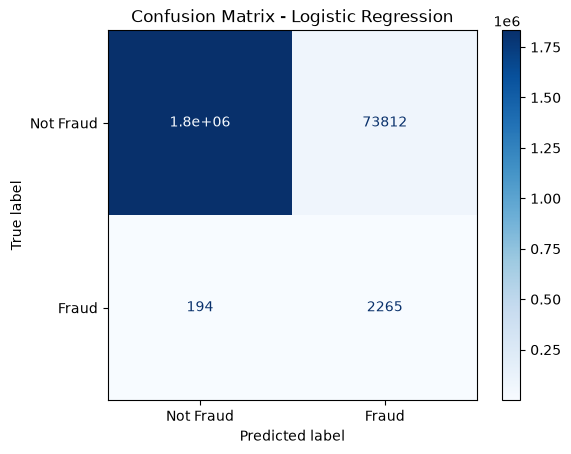

In [44]:
log_reg_results = evaluate_model('Logistic Regression', log_reg, X_test, y_test)

**Decision Tree**

-_- Decision Tree -_-
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1906165
       Fraud       0.89      0.84      0.86      2459

    accuracy                           1.00   1908624
   macro avg       0.94      0.92      0.93   1908624
weighted avg       1.00      1.00      1.00   1908624

Precision (Fraud): 0.8859
Recall (Fraud):    0.8398
F1-score (Fraud):  0.8622
PR-AUC:            0.7441


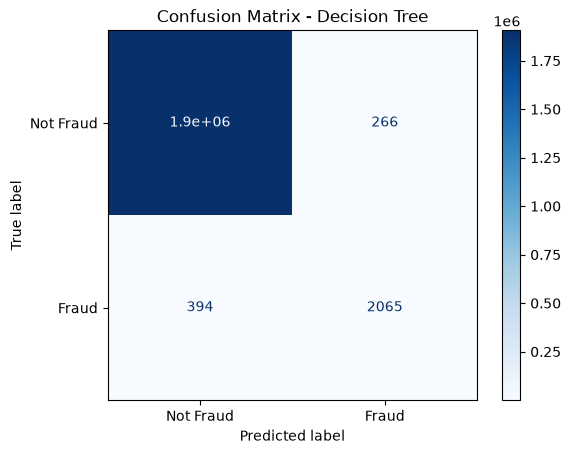

In [45]:
dt_results = evaluate_model('Decision Tree', dt_model, X_test, y_test)

**Random Forest**

-_- Random Forest -_-
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1906165
       Fraud       0.93      0.84      0.88      2459

    accuracy                           1.00   1908624
   macro avg       0.97      0.92      0.94   1908624
weighted avg       1.00      1.00      1.00   1908624

Precision (Fraud): 0.9311
Recall (Fraud):    0.8410
F1-score (Fraud):  0.8838
PR-AUC:            0.9472


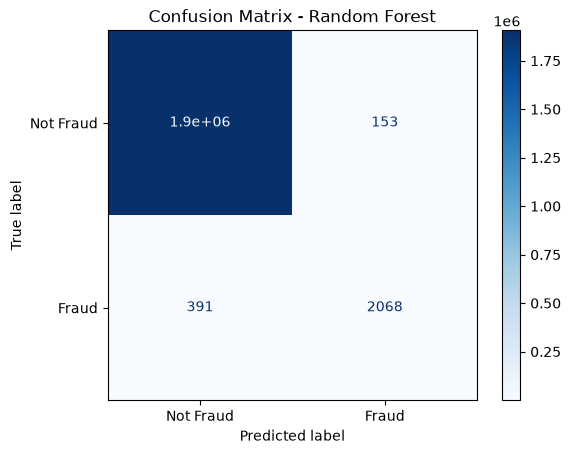

In [46]:
rf_results = evaluate_model('Random Forest', rf_model, X_test, y_test)

**Precision-Recall Curve Comparison**

1. `Random Forest` is the clear winner, with a percision recall-curve of 0.947. It maintains high recall levels, catching allmost all fraudulent transaction without throwing many false alarms.
2. `Descision Tree` performs decently wutg a PR-AUC of 0.74. In this graph, we can notice a sharp angular line which shows that it uses rigid bounderies when detecting fraudlent transactions, making it less refined than RF.
3. `Logistic Regression` performs the poorest with a percision recall curve of 0.572; its curve drops sharply early on. This affirms our earlier hypothesis during EDA that linear models struggle to speparate frad from non-fraud.

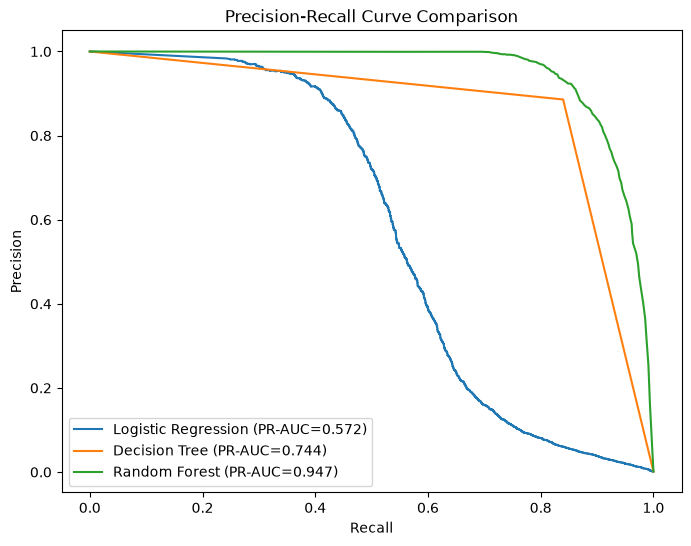

In [47]:
plt.figure(figsize=(8,6))

for results, model in [(log_reg_results, log_reg), (dt_results, dt_model), (rf_results, rf_model)]:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, results['y_proba'])
    plt.plot(recall_vals, precision_vals, label=f"{results['model']} (PR-AUC={results['pr_auc']:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

**Model Comparison Summary**

Building off last cell's conslusion, we can further infer the the following points by observing the summary of each model:

1. While recall is high (92.1%), the percision of `Logistic Regression` is extremely low (2.9%). This means that around 97% of all detected frauds are false alarms.
2. Across all the board, `Random Forest` is the best performing model. It maintains high precision (93.1) alongside strong recall (84.1), yielding an impressive pr-auc of 0.9472

In [48]:
comparison_df = pd.DataFrame([
    {k: v for k, v in log_reg_results.items() if k != 'y_proba'},
    {k: v for k, v in dt_results.items() if k != 'y_proba'},
    {k: v for k, v in rf_results.items() if k != 'y_proba'},
]).set_index('model').round(4)

comparison_df

,precision,recall,f1,pr_auc
model,,,,
Logistic Regression,0.0298,0.9211,0.0577,0.5720
Decision Tree,0.8859,0.8398,0.8622,0.7441
Random Forest,0.9311,0.8410,0.8838,0.9472
